# Heart Disease Prediction — Kaggle Playground S6E2

**Goal:** Predict the presence or absence of heart disease from clinical features.  
**Metric:** ROC-AUC (higher is better, max = 1.0)  
**Approach:** First-principles learning — understand why before how.

---

## How to read this notebook

Every section starts with an explanation block (like this one) that answers:  
- **What** are we doing?  
- **Why** does it matter?  
- **What should we expect** to find?

Then comes the code. Read the explanation first, then run the code, then think about what you see.

---
# Phase 1 — Exploratory Data Analysis (EDA)

**First principle:** Never touch a model before you understand your data.  

EDA is not optional cleanup — it is *the most important step*. It tells you:  
1. Are there data quality issues? (missing values, outliers, wrong types)  
2. What does the target distribution look like? (balanced? skewed?)  
3. Which features are informative? (do they vary with the target?)  
4. Are features correlated with each other? (multicollinearity)  

Everything you find here shapes your modelling decisions.

In [1]:
# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('muted')

print('Libraries loaded.')

Libraries loaded.


## 1.1 — Load the Data

Always start by just *looking* at the raw data.  
Check: shape, column names, dtypes, and the first few rows.

In [2]:
DATA_DIR = 'Dataset/'

train = pd.read_csv(DATA_DIR + 'train.csv')
test  = pd.read_csv(DATA_DIR + 'test.csv')
sub   = pd.read_csv(DATA_DIR + 'sample_submission.csv')

print(f'Train shape : {train.shape}')
print(f'Test shape  : {test.shape}')
print(f'Submission  : {sub.shape}')

train.head()

Train shape : (630000, 15)
Test shape  : (270000, 14)
Submission  : (270000, 2)


,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.600,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.000,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.000,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.000,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.800,2,3,3,Presence


In [3]:
# Data types and memory usage
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 non-null  int64  
 14  Heart Disease  

## 1.2 — Missing Values

**Why this matters:** Most ML algorithms cannot handle NaN values — they'll error out or silently produce garbage predictions.  
We need to know *how many* values are missing and *which features* have them before deciding how to handle them.

Strategies (we'll choose based on what we find):  
- **Drop rows** — only if very few rows are affected  
- **Fill with median/mode** — simple and usually fine for tree-based models  
- **Fill with model** — overkill for most cases

In [4]:
missing_train = train.isnull().sum()
missing_test  = test.isnull().sum()

missing = pd.DataFrame({
    'Train Missing'  : missing_train,
    'Train %'        : (missing_train / len(train) * 100).round(2),
    'Test Missing'   : missing_test,
    'Test %'         : (missing_test  / len(test)  * 100).round(2),
})

missing[missing['Train Missing'] > 0]

,Train Missing,Train %,Test Missing,Test %


In [5]:
# Summary statistics — check for unusual min/max values
train.describe()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,630000.000,630000.000,630000.000,630000.000,630000.000,630000.000,630000.000,630000.000,630000.000,630000.000,630000.000,630000.000,630000.000,630000.000
mean,314999.500,54.137,0.715,3.313,130.497,245.012,0.080,0.982,152.817,0.274,0.716,1.456,0.451,4.619
std,181865.479,8.256,0.452,0.852,14.976,33.682,0.271,0.999,19.113,0.446,0.948,0.545,0.799,1.950
min,0.000,29.000,0.000,1.000,94.000,126.000,0.000,0.000,71.000,0.000,0.000,1.000,0.000,3.000
25%,157499.750,48.000,0.000,3.000,120.000,223.000,0.000,0.000,142.000,0.000,0.000,1.000,0.000,3.000
50%,314999.500,54.000,1.000,4.000,130.000,243.000,0.000,0.000,157.000,0.000,0.100,1.000,0.000,3.000
75%,472499.250,60.000,1.000,4.000,140.000,269.000,0.000,2.000,166.000,1.000,1.400,2.000,1.000,7.000
max,629999.000,77.000,1.000,4.000,200.000,564.000,1.000,2.000,202.000,1.000,6.200,3.000,3.000,7.000


## 1.3 — Target Distribution

**Why this matters:** If 95% of patients have "Absence" and only 5% have "Presence",  
a model that always predicts "Absence" would be 95% accurate — but completely useless.  

Class imbalance affects:  
- Which metric to use (ROC-AUC is robust to imbalance; accuracy is not)  
- Whether we need to oversample/undersample  
- How we interpret model outputs

Target distribution:
         Count  Percent
target                 
0       347546   55.200
1       282454   44.800


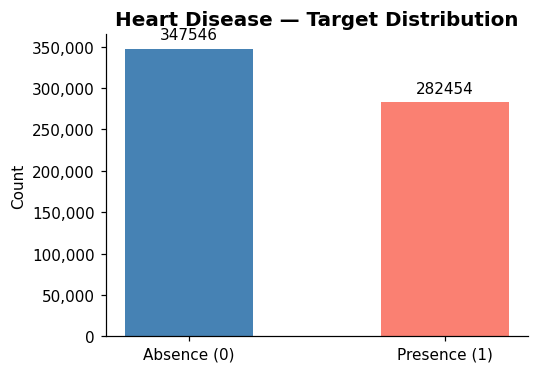

In [6]:
# Encode target: Presence=1, Absence=0
train['target'] = (train['Heart Disease'] == 'Presence').astype(int)

counts = train['target'].value_counts()
pct    = train['target'].value_counts(normalize=True) * 100

print('Target distribution:')
print(pd.DataFrame({'Count': counts, 'Percent': pct.round(1)}))

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(['Absence (0)', 'Presence (1)'], counts.sort_index(), color=['steelblue', 'salmon'], width=0.5)
ax.bar_label(ax.containers[0], fmt='%d', padding=4, fontsize=10)
ax.set_title('Heart Disease — Target Distribution', fontsize=13, fontweight='bold')
ax.set_ylabel('Count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

## 1.4 — Feature Reference

Before visualizing, let's understand what each feature *means* clinically.  
This matters because domain knowledge guides feature engineering decisions later.

| Feature | Type | Medical Meaning |
|---|---|---|
| Age | Continuous | Patient age in years — older = higher risk |
| Sex | Binary | 1 = Male, 0 = Female — men have higher risk at younger ages |
| Chest pain type | Categorical | 1=typical angina, 2=atypical, 3=non-anginal, 4=asymptomatic |
| BP | Continuous | Resting blood pressure (mmHg) — high BP is a risk factor |
| Cholesterol | Continuous | Serum cholesterol mg/dl — high levels clog arteries |
| FBS over 120 | Binary | Fasting blood sugar > 120 mg/dl — proxy for diabetes |
| EKG results | Categorical | Electrical heart activity: 0=normal, 1=ST-T wave abnormality, 2=LV hypertrophy |
| Max HR | Continuous | Max heart rate achieved — lower max HR can indicate disease |
| Exercise angina | Binary | Chest pain during exercise — strong signal |
| ST depression | Continuous | ECG drop during exercise — important cardiac marker |
| Slope of ST | Categorical | 1=upsloping (good), 2=flat, 3=downsloping (bad) |
| Number of vessels fluro | Continuous | 0–3 vessels visible on fluoroscopy — more = more disease |
| Thallium | Categorical | Blood flow scan: 3=normal, 6=fixed defect, 7=reversible defect |

## 1.5 — Feature Distributions

**What to look for:**  
- **Continuous features:** Are they roughly normal? Skewed? Any extreme outliers?  
- **Categorical features:** Are all expected values present? Any unexpected values?  
- **Do distributions shift between the 0 and 1 class?** This is the core signal.

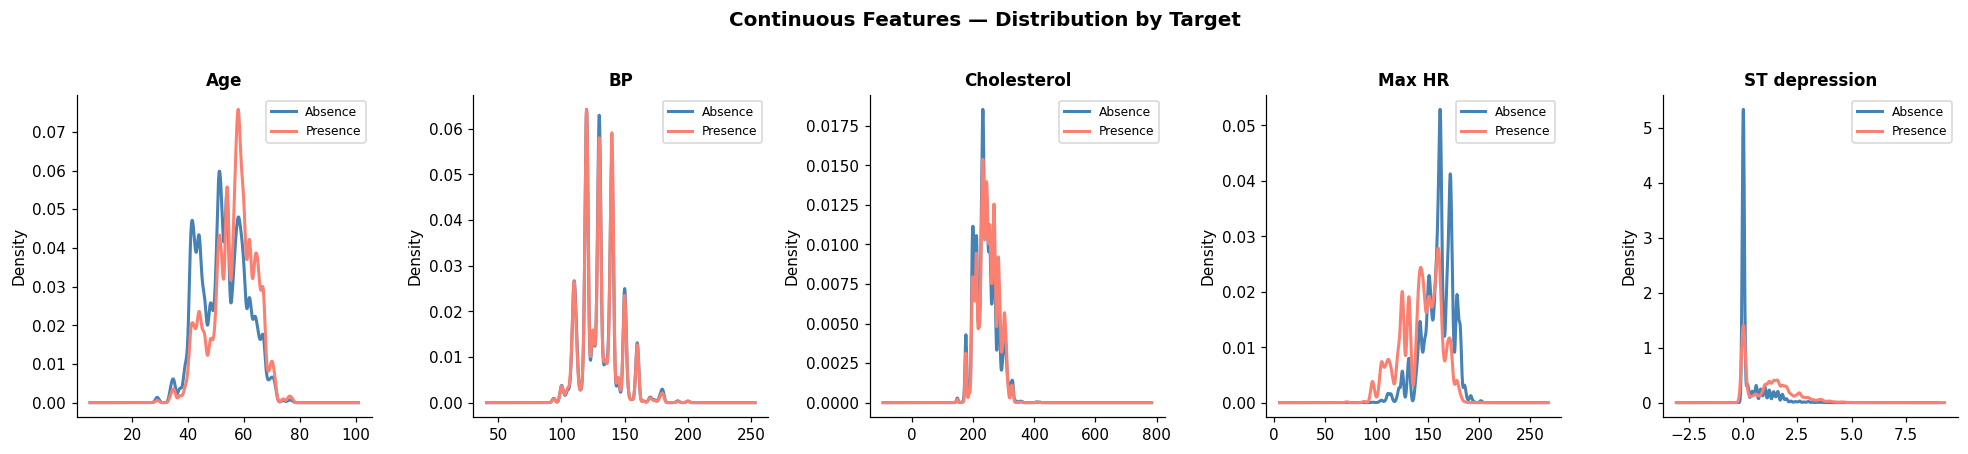

In [7]:
# Split feature names by type
CONTINUOUS   = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']
CATEGORICAL  = ['Sex', 'Chest pain type', 'FBS over 120', 'EKG results',
                'Exercise angina', 'Slope of ST', 'Number of vessels fluro', 'Thallium']

# Continuous features — KDE split by target
fig, axes = plt.subplots(1, len(CONTINUOUS), figsize=(18, 4))
for ax, col in zip(axes, CONTINUOUS):
    for val, label, color in [(0, 'Absence', 'steelblue'), (1, 'Presence', 'salmon')]:
        subset = train.loc[train['target'] == val, col]
        subset.plot.kde(ax=ax, label=label, color=color, linewidth=2)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.legend(fontsize=8)
fig.suptitle('Continuous Features — Distribution by Target', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

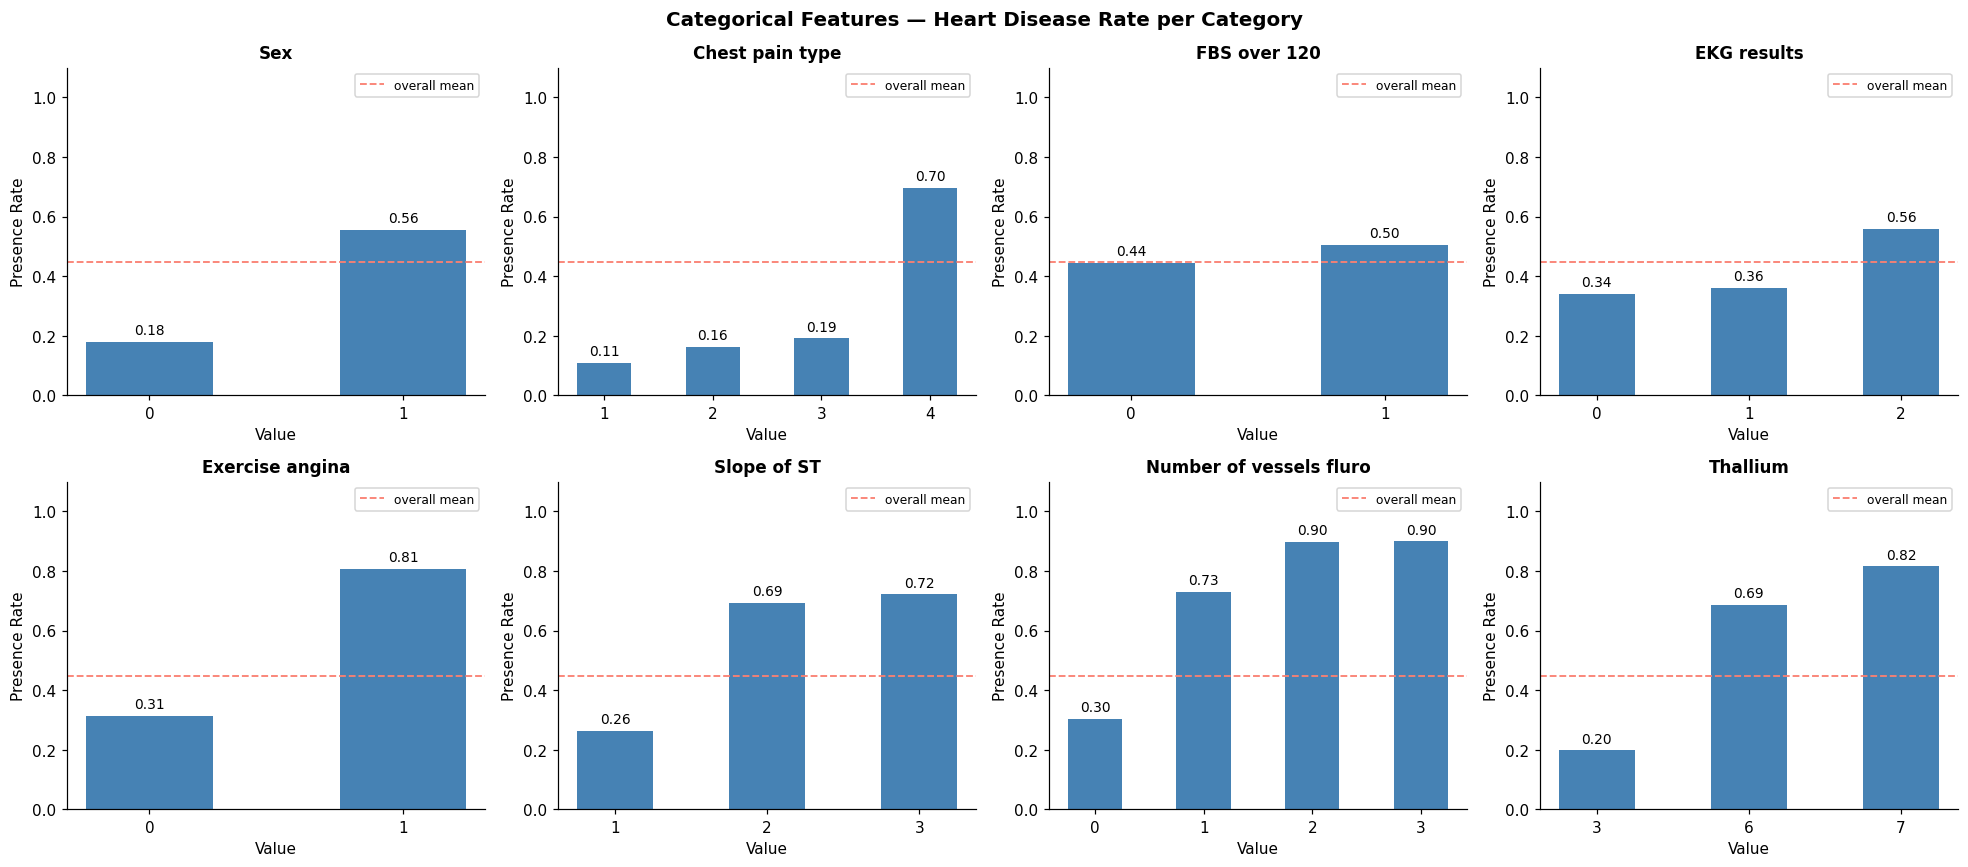

In [8]:
# Categorical features — Disease rate per category value
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, col in zip(axes, CATEGORICAL):
    rate = train.groupby(col)['target'].mean().sort_index()
    bars = ax.bar(rate.index.astype(str), rate.values, color='steelblue', width=0.5)
    ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=9)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Presence Rate')
    ax.set_xlabel('Value')
    ax.axhline(train['target'].mean(), color='salmon', linestyle='--', linewidth=1.2, label='overall mean')
    ax.legend(fontsize=8)

fig.suptitle('Categorical Features — Heart Disease Rate per Category', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 1.6 — Correlation Analysis

**Pearson correlation with target** tells us: for continuous features, which direction does the feature move as disease risk increases?  

Limitations to keep in mind:  
- Pearson only captures *linear* relationships — a feature can be important even with low correlation  
- Correlated features carry redundant information (but tree models handle this fine)  

**Point-biserial correlation** is the right term when one variable is binary — but numerically it equals Pearson, so we use `.corr()` directly.

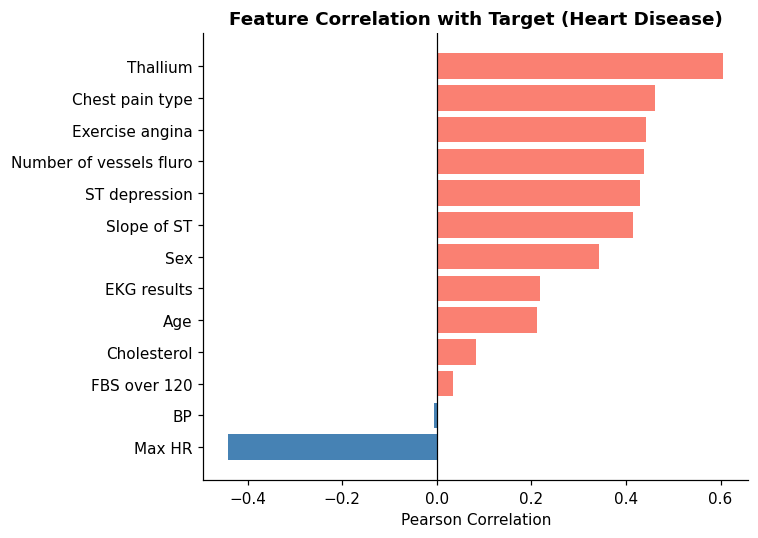


Top positive correlators (increase disease risk):
ST depression             0.431
Number of vessels fluro   0.439
Exercise angina           0.442
Chest pain type           0.461
Thallium                  0.606

Top negative correlators (decrease disease risk):
Max HR   -0.441
BP       -0.005


In [9]:
# Encode categoricals as integers for correlation
feature_cols = CONTINUOUS + CATEGORICAL
corr_with_target = train[feature_cols + ['target']].corr()['target'].drop('target').sort_values()

fig, ax = plt.subplots(figsize=(7, 5))
colors = ['salmon' if v > 0 else 'steelblue' for v in corr_with_target.values]
bars = ax.barh(corr_with_target.index, corr_with_target.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with Target (Heart Disease)', fontsize=12, fontweight='bold')
ax.set_xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

print('\nTop positive correlators (increase disease risk):')
print(corr_with_target[corr_with_target > 0].tail(5).to_string())
print('\nTop negative correlators (decrease disease risk):')
print(corr_with_target[corr_with_target < 0].head(5).to_string())

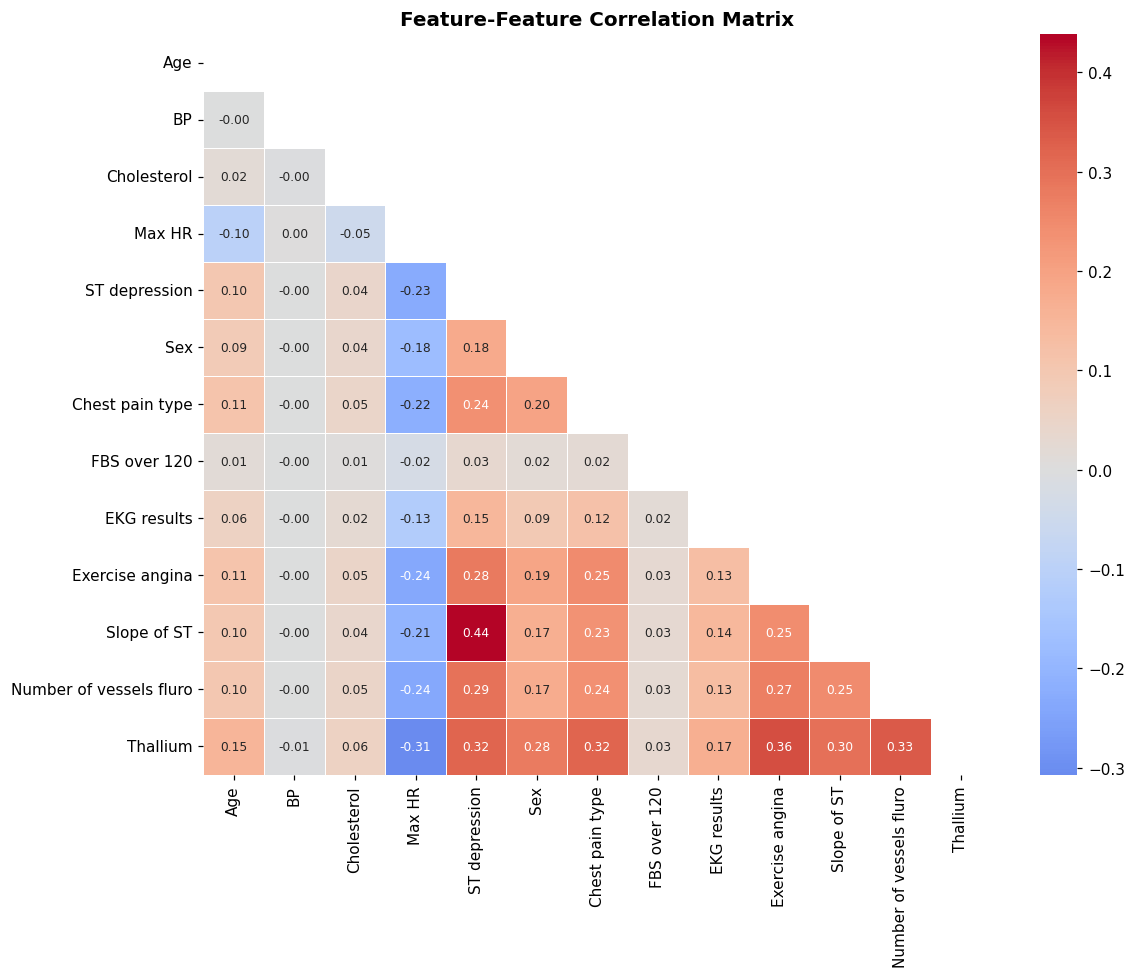

In [10]:
# Feature-feature correlation heatmap
# Why: if two features are highly correlated (e.g. > 0.8), they carry near-identical information.
# This doesn't hurt tree models but is important to know.

corr_matrix = train[feature_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # show lower triangle only
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    annot_kws={'size': 8}, ax=ax
)
ax.set_title('Feature-Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 1.7 — Distribution Shift: Train vs Test

**Why this matters:** If the test data has a different distribution than train data, your model may not generalize well.  
This is called **covariate shift** — the inputs changed even if the underlying relationship didn't.

We check this by comparing the mean and std of each feature across train and test.

In [11]:
train_stats = train[feature_cols].agg(['mean', 'std']).T.rename(columns={'mean': 'train_mean', 'std': 'train_std'})
test_stats  = test[feature_cols].agg(['mean', 'std']).T.rename(columns={'mean': 'test_mean',  'std': 'test_std'})

shift = pd.concat([train_stats, test_stats], axis=1)
shift['mean_diff_%'] = ((shift['test_mean'] - shift['train_mean']) / shift['train_mean'].abs().clip(lower=1e-6) * 100).round(2)

shift.sort_values('mean_diff_%', key=abs, ascending=False)

,train_mean,train_std,test_mean,test_std,mean_diff_%
Number of vessels fluro,0.451,0.799,0.455,0.801,0.830
Exercise angina,0.274,0.446,0.275,0.446,0.340
EKG results,0.982,0.999,0.978,0.999,-0.320
ST depression,0.716,0.948,0.718,0.947,0.290
Slope of ST,1.456,0.545,1.459,0.546,0.240
Sex,0.715,0.452,0.716,0.451,0.220
FBS over 120,0.080,0.271,0.080,0.271,0.080
Chest pain type,3.313,0.852,3.315,0.852,0.070
Age,54.137,8.256,54.160,8.255,0.040
BP,130.497,14.976,130.555,15.008,0.040


## 1.8 — EDA Summary

Fill in after running the cells above.

**Class balance:**  
- *(e.g. roughly balanced / imbalanced at X%)*

**Missing values:**  
- *(e.g. none / feature X has Y% missing)*

**Strongest predictors (from correlation chart):**  
- Positive (increase risk): *...*  
- Negative (decrease risk): *...*

**Notable patterns:**  
- *(e.g. Chest pain type 4 = asymptomatic has highest disease rate, which is counterintuitive — investigate)*

**Distribution shift between train and test:**  
- *(e.g. minimal / feature X shows notable shift)*

**Decisions for modelling:**  
- [ ] Encode target as 0/1  
- [ ] Handle any missing values  
- [ ] All features are already numeric — no text encoding needed  
- [ ] *(anything else you discovered)*

---
# Phase 2 — Baseline Model: Logistic Regression

**First principle:** Before reaching for powerful models, build the *simplest possible* model first.

Logistic Regression is our baseline for three reasons:
1. **Interpretable** — every coefficient has a direct, numeric meaning (log-odds)
2. **Fast** — trains in seconds even on 630K rows
3. **Sets the bar** — any more complex model must beat this score to justify its added complexity

Sections in this phase:
- **2.1** The math: sigmoid, log-odds, decision boundary
- **2.2** Cross-validation: why a single split isn't enough
- **2.3** ROC-AUC: what it actually measures
- **2.4** Confusion matrix and the precision-recall tradeoff
- **2.5** Coefficient interpretation: which features drive the prediction?
- **2.6** Summary and baseline score

## 2.1 — The Math: Why Does Logistic Regression Work?

### The core problem
Linear regression predicts a number on (−∞, +∞). But we need a *probability* in [0, 1].  
The fix: squash the linear output through the **sigmoid function**:

```
σ(z) = 1 / (1 + e^(-z))      where z = w₀ + w₁x₁ + w₂x₂ + ...
```

No matter how large or small `z` is, `σ(z)` always lands in (0, 1). That's our predicted probability.

### Log-odds (the "logit")
Rearranging: `z = log(p / (1−p))` — the *log of the odds ratio*.  
A coefficient `w₁` means: **each 1-unit increase in x₁ changes the log-odds of disease by w₁**.  
Exponentiate it (`e^w₁`) and you get the **odds ratio** — how many times more likely disease becomes.

### Decision boundary
Logistic regression predicts class 1 when `σ(z) ≥ 0.5`, which means `z ≥ 0`.  
In 2D feature space, `z = 0` is a *straight line* — this is a **linear classifier**.  
Key limitation: if the true boundary is curved, logistic regression cannot capture it.

### What it optimizes
It minimizes **binary cross-entropy** (log-loss):
```
Loss = −[y·log(p) + (1−y)·log(1−p)]
```
When the true label is 1 and we predict p≈0 (very confident and wrong), log(p) → −∞ → huge penalty.  
This asymmetric penalty forces the model to be well-calibrated, not just accurate.

### Feature scaling is required
The gradient descent optimizer that fits the weights is sensitive to the *scale* of features.  
If `Age` ranges 29–77 and `ST depression` ranges 0–6.2, the optimizer has to take very different-sized steps.  
**StandardScaler** (subtract mean, divide by std) puts all features on the same scale → faster convergence, better numerical stability.

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Feature columns (same order as EDA)
FEATURE_COLS = [
    'Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression',      # continuous
    'Sex', 'Chest pain type', 'FBS over 120', 'EKG results',    # categorical (already int)
    'Exercise angina', 'Slope of ST', 'Number of vessels fluro', 'Thallium'
]

X = train[FEATURE_COLS].values
y = train['target'].values   # already encoded in Phase 1: 1=Presence, 0=Absence

print(f'X shape : {X.shape}')
print(f'y shape : {y.shape}')
print(f'Positive rate : {y.mean():.3f}  ({y.sum():,} / {len(y):,})')
print()

# Visualise why scaling matters
raw_stats = train[FEATURE_COLS].agg(['min', 'max', 'std'])
print('Feature ranges BEFORE scaling:')
print(raw_stats.T.to_string())

X shape : (630000, 13)
y shape : (630000,)
Positive rate : 0.448  (282,454 / 630,000)

Feature ranges BEFORE scaling:
                            min     max    std
Age                      29.000  77.000  8.256
BP                       94.000 200.000 14.976
Cholesterol             126.000 564.000 33.682
Max HR                   71.000 202.000 19.113
ST depression             0.000   6.200  0.948
Sex                       0.000   1.000  0.452
Chest pain type           1.000   4.000  0.852
FBS over 120              0.000   1.000  0.271
EKG results               0.000   2.000  0.999
Exercise angina           0.000   1.000  0.446
Slope of ST               1.000   3.000  0.545
Number of vessels fluro   0.000   3.000  0.799
Thallium                  3.000   7.000  1.950


## 2.2 — Cross-Validation: Why One Split Is Not Enough

### The problem with a single train/val split
If you split 80% train / 20% val and get AUC = 0.87, is that trustworthy?  
Maybe you got lucky: your 20% happened to be easy to predict.  
Or unlucky: your 20% was unusually hard. You have no way to know.

### 5-Fold Stratified Cross-Validation
We split the data into 5 equal-sized **folds**. In each round:
- 4 folds = training set
- 1 fold = validation set (the model has *never seen this data*)

Repeat 5 times so every row appears in the validation set exactly once.  
Average the 5 AUC scores → much more stable estimate of true model performance.

**Stratified** means each fold has the same class ratio as the full dataset.  
This matters for imbalanced problems (though ours is nearly balanced).

### Out-of-Fold (OOF) predictions
Collecting the val-fold predictions across all 5 rounds gives us **OOF predictions** —  
a valid predicted probability for every single training row, with **zero data leakage**.

OOF predictions are gold: we use them later to blend models in Phase 5.

In [13]:
N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

oof_preds = np.zeros(len(y))   # will hold OOF probabilities for every training row
fold_aucs = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
    X_tr, X_val = X[train_idx], X[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]

    # Scale INSIDE the fold — fit scaler only on train, apply to val
    # (fitting on all data would leak val statistics into training)
    scaler = StandardScaler()
    X_tr_scaled  = scaler.fit_transform(X_tr)
    X_val_scaled = scaler.transform(X_val)

    model = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
    model.fit(X_tr_scaled, y_tr)

    val_proba = model.predict_proba(X_val_scaled)[:, 1]  # P(class=1)
    oof_preds[val_idx] = val_proba

    fold_auc = roc_auc_score(y_val, val_proba)
    fold_aucs.append(fold_auc)
    print(f'  Fold {fold}  |  val AUC = {fold_auc:.5f}  |  val rows = {len(val_idx):,}')

oof_auc = roc_auc_score(y, oof_preds)
print(f'\n  Mean fold AUC : {np.mean(fold_aucs):.5f}  ±  {np.std(fold_aucs):.5f}')
print(f'  OOF AUC       : {oof_auc:.5f}  ← use this as the single summary score')

  Fold 1  |  val AUC = 0.95075  |  val rows = 126,000
  Fold 2  |  val AUC = 0.94996  |  val rows = 126,000


  Fold 3  |  val AUC = 0.95078  |  val rows = 126,000
  Fold 4  |  val AUC = 0.95022  |  val rows = 126,000


  Fold 5  |  val AUC = 0.95074  |  val rows = 126,000

  Mean fold AUC : 0.95049  ±  0.00034
  OOF AUC       : 0.95049  ← use this as the single summary score


## 2.3 — ROC-AUC: What Does It Actually Measure?

### The ROC curve
At every possible **threshold** t (from 0 → 1), we ask:
- "If I predict disease when predicted probability ≥ t, what's my True Positive Rate (TPR) and False Positive Rate (FPR)?"

**TPR** (Recall/Sensitivity) = of all real positives, how many did we catch?  
**FPR** = of all real negatives, how many did we falsely flag?

Sweeping t from 1 → 0 traces a curve from (0,0) to (1,1).  
A perfect model: TPR=1, FPR=0, curve hugs the top-left corner.  
A random model: diagonal line (TPR ≈ FPR always), AUC = 0.5.

### AUC (Area Under the Curve)
A single number summary: the probability that a **randomly chosen positive** patient gets a higher predicted score than a **randomly chosen negative** patient.

- AUC = 1.0 → perfect separation
- AUC = 0.5 → random (useless)
- AUC = 0.9 → very strong
- AUC = 0.75 → decent, room to improve

AUC is **threshold-independent** — it evaluates the quality of the *ranking*, not any specific cutoff.  
This is exactly why Kaggle uses it: you submit probabilities, not hard labels.

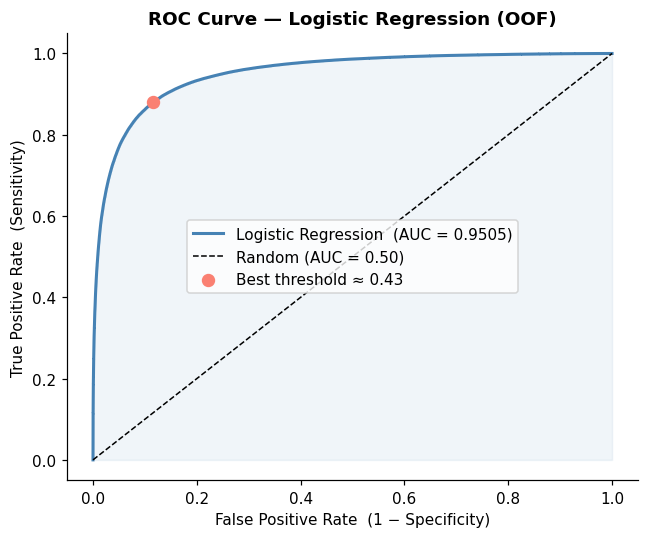

Optimal threshold (min distance to top-left): 0.431
  TPR at that point : 0.880
  FPR at that point : 0.116


In [14]:
# ROC curve from OOF predictions (the most honest estimate we have)
fpr, tpr, thresholds = roc_curve(y, oof_preds)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='steelblue', lw=2, label=f'Logistic Regression  (AUC = {oof_auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.50)')
ax.fill_between(fpr, tpr, alpha=0.08, color='steelblue')

# Mark the "optimal" operating point — closest to top-left
dist_to_corner = np.sqrt((fpr)**2 + (1 - tpr)**2)
best_idx = np.argmin(dist_to_corner)
ax.scatter(fpr[best_idx], tpr[best_idx], color='salmon', zorder=5, s=60,
           label=f'Best threshold ≈ {thresholds[best_idx]:.2f}')

ax.set_xlabel('False Positive Rate  (1 − Specificity)')
ax.set_ylabel('True Positive Rate  (Sensitivity)')
ax.set_title('ROC Curve — Logistic Regression (OOF)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f'Optimal threshold (min distance to top-left): {thresholds[best_idx]:.3f}')
print(f'  TPR at that point : {tpr[best_idx]:.3f}')
print(f'  FPR at that point : {fpr[best_idx]:.3f}')

## 2.4 — Confusion Matrix and the Precision-Recall Tradeoff

### The four outcomes at a fixed threshold
Once you pick a threshold (e.g. 0.5), every prediction is either:

|  | Predicted 0 | Predicted 1 |
|---|---|---|
| **True 0** | True Negative (TN) ✓ | False Positive (FP) ✗ |
| **True 1** | False Negative (FN) ✗ | True Positive (TP) ✓ |

**False Negative** = missed a sick patient → dangerous in medicine.  
**False Positive** = healthy patient flagged → costly in over-treatment.

### Precision vs Recall
- **Precision** = TP / (TP + FP) — of patients we flagged, how many are truly sick?
- **Recall** = TP / (TP + FN) — of all truly sick patients, how many did we catch?

**There is always a tradeoff:** lower the threshold → more positives flagged → recall ↑, precision ↓.  
Which matters more depends on the *cost* of each error type. In heart disease screening, missing a case (FN) is usually worse than an unnecessary follow-up (FP), so we prefer **high recall**.

Note: for Kaggle submission we submit probabilities and Kaggle picks the threshold — so AUC is what counts.  
But the confusion matrix helps us understand *where* the model is making mistakes.

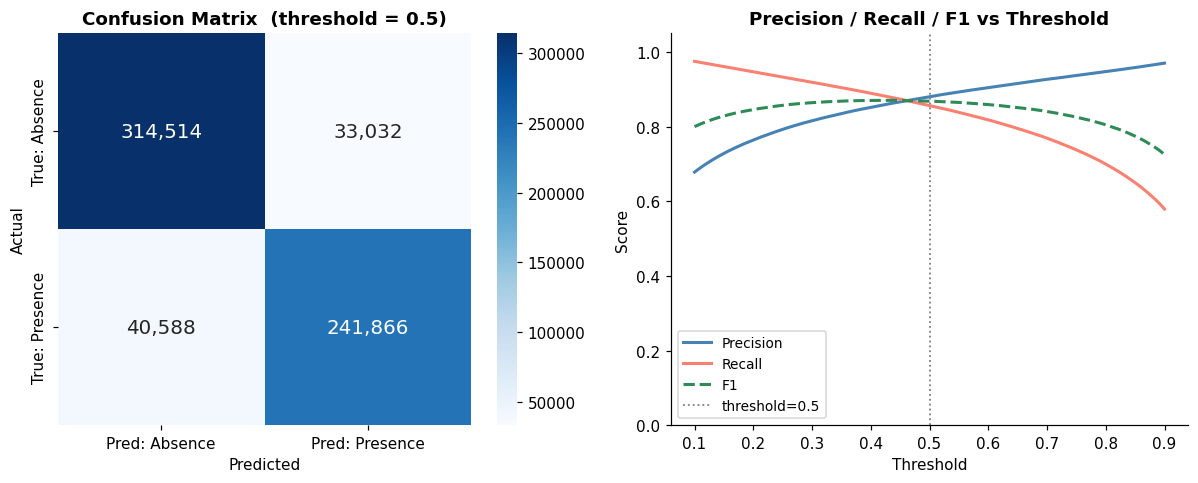


Classification report at threshold = 0.5:
              precision    recall  f1-score   support

     Absence       0.89      0.90      0.90    347546
    Presence       0.88      0.86      0.87    282454

    accuracy                           0.88    630000
   macro avg       0.88      0.88      0.88    630000
weighted avg       0.88      0.88      0.88    630000



In [15]:
# Use OOF predictions with threshold = 0.5
oof_labels = (oof_preds >= 0.5).astype(int)
cm = confusion_matrix(y, oof_labels)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# --- Confusion matrix heatmap ---
ax = axes[0]
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=ax,
            xticklabels=['Pred: Absence', 'Pred: Presence'],
            yticklabels=['True: Absence', 'True: Presence'],
            annot_kws={'size': 13})
ax.set_title('Confusion Matrix  (threshold = 0.5)', fontsize=12, fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')

# --- Precision-Recall tradeoff across thresholds ---
ax = axes[1]
thresh_vals = np.linspace(0.1, 0.9, 200)
precisions, recalls, f1s = [], [], []
for t in thresh_vals:
    preds_t = (oof_preds >= t).astype(int)
    if preds_t.sum() == 0:
        precisions.append(np.nan); recalls.append(np.nan); f1s.append(np.nan)
        continue
    p = tp_t = ((preds_t == 1) & (y == 1)).sum() / preds_t.sum()
    r = tp_t2 = ((preds_t == 1) & (y == 1)).sum() / y.sum()
    precisions.append(p); recalls.append(r)
    f1s.append(2*p*r/(p+r) if (p+r) > 0 else 0)

ax.plot(thresh_vals, precisions, label='Precision', color='steelblue', lw=2)
ax.plot(thresh_vals, recalls,   label='Recall',    color='salmon',    lw=2)
ax.plot(thresh_vals, f1s,       label='F1',        color='seagreen',  lw=2, linestyle='--')
ax.axvline(0.5, color='gray', linestyle=':', lw=1.2, label='threshold=0.5')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 vs Threshold', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

print('\nClassification report at threshold = 0.5:')
print(classification_report(y, oof_labels, target_names=['Absence', 'Presence']))

## 2.5 — Interpreting the Coefficients

### What each coefficient tells you
The trained weights `w₁, w₂, ...` are the *coefficients* of the linear combination `z = Σ wᵢxᵢ`.

Because we scaled all features to mean=0, std=1 before training:
- Coefficients are **directly comparable** — a larger |w| means stronger influence.
- **Positive w** → feature increases the log-odds of Presence (disease more likely).
- **Negative w** → feature decreases the log-odds of Presence (disease less likely).

To convert to odds ratios: `OR = e^w`.  
OR > 1 → feature increases odds; OR < 1 → feature decreases odds.

### What we expect to see (from EDA)
From Phase 1 we found that high ST depression, asymptomatic chest pain (type 4), more vessels fluoro'd, and reversible Thallium defect all correlated with disease presence.  
If LR learned correctly, these features should have the largest positive coefficients.

                Feature  Coefficient  Odds Ratio
                 Max HR       -0.838       0.433
           FBS over 120       -0.011       0.989
                     BP        0.004       1.004
            Cholesterol        0.097       1.102
            EKG results        0.219       1.245
                    Age        0.352       1.422
            Slope of ST        0.444       1.559
          ST depression        0.462       1.588
                    Sex        0.483       1.622
        Exercise angina        0.542       1.719
Number of vessels fluro        0.705       2.025
        Chest pain type        0.888       2.431
               Thallium        0.963       2.621

Intercept: -0.2789


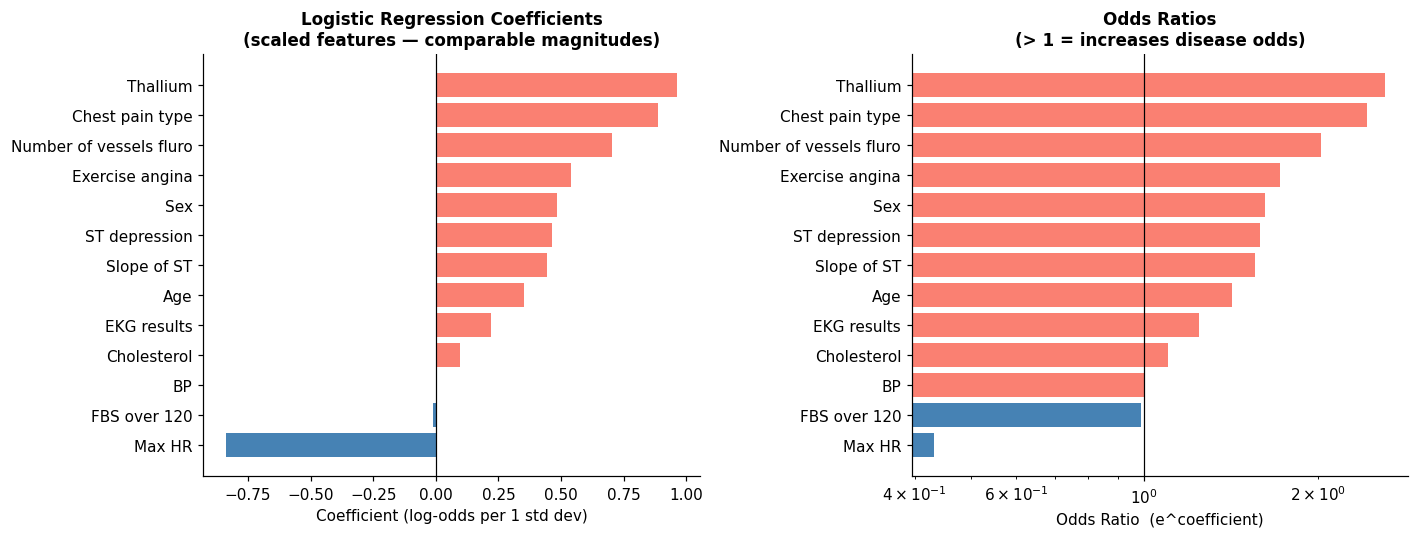

In [16]:
# Train final model on ALL training data (for coefficient inspection and test predictions)
final_scaler = StandardScaler()
X_scaled_all = final_scaler.fit_transform(X)

final_model = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
final_model.fit(X_scaled_all, y)

# Build coefficient table
coef_df = pd.DataFrame({
    'Feature'      : FEATURE_COLS,
    'Coefficient'  : final_model.coef_[0],
    'Odds Ratio'   : np.exp(final_model.coef_[0])
}).sort_values('Coefficient')

print(coef_df.to_string(index=False))
print(f'\nIntercept: {final_model.intercept_[0]:.4f}')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Coefficient bar chart
ax = axes[0]
colors = ['salmon' if v > 0 else 'steelblue' for v in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression Coefficients\n(scaled features — comparable magnitudes)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Coefficient (log-odds per 1 std dev)')

# Odds ratio bar chart (log scale makes it symmetric around 1)
ax = axes[1]
colors2 = ['salmon' if v > 1 else 'steelblue' for v in coef_df['Odds Ratio']]
ax.barh(coef_df['Feature'], coef_df['Odds Ratio'], color=colors2)
ax.axvline(1, color='black', linewidth=0.8)
ax.set_title('Odds Ratios\n(> 1 = increases disease odds)', fontsize=11, fontweight='bold')
ax.set_xlabel('Odds Ratio  (e^coefficient)')
ax.set_xscale('log')

plt.tight_layout()
plt.show()

## 2.6 — Generate Test Predictions

Before summarizing, let's produce test-set probabilities from the final model.  
These are what we'd submit to Kaggle (we'll do the actual submission in Phase 5 after blending).

Test predictions shape : (270000,)
Test pred mean         : 0.4497
Test pred range        : [0.0002, 1.0000]


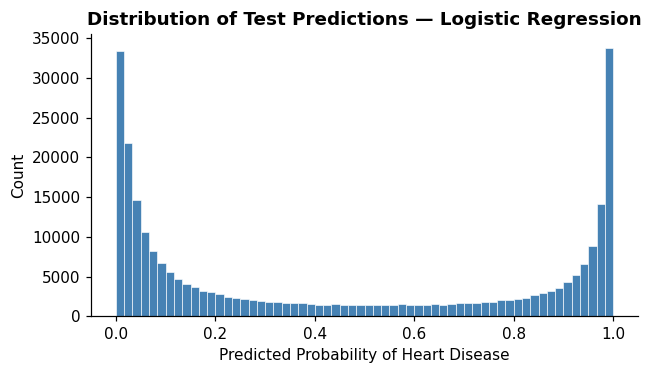

In [17]:
X_test = test[FEATURE_COLS].values
X_test_scaled = final_scaler.transform(X_test)   # use scaler fit on full train — no leakage

lr_test_preds = final_model.predict_proba(X_test_scaled)[:, 1]

print(f'Test predictions shape : {lr_test_preds.shape}')
print(f'Test pred mean         : {lr_test_preds.mean():.4f}')
print(f'Test pred range        : [{lr_test_preds.min():.4f}, {lr_test_preds.max():.4f}]')

# Quick sanity check: distribution of test predictions
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(lr_test_preds, bins=60, color='steelblue', edgecolor='white', linewidth=0.4)
ax.set_xlabel('Predicted Probability of Heart Disease')
ax.set_ylabel('Count')
ax.set_title('Distribution of Test Predictions — Logistic Regression', fontweight='bold')
plt.tight_layout()
plt.show()

## 2.7 — Phase 2 Summary

Fill in after running the cells above.

**Baseline OOF ROC-AUC:** *(record the number here)*

**What the model learned (from coefficients):**
- Strongest risk-increasing features: *(e.g. Chest pain type, ST depression, ...)*
- Strongest risk-decreasing features: *(e.g. Max HR, ...)*
- Does this match what EDA suggested? *(yes/no/partially)*

**Confusion matrix observations (at threshold = 0.5):**
- False negative rate: *(FN / all true positives)* — patients we missed
- False positive rate: *(FP / all true negatives)* — healthy patients we over-flagged

**Key limitations of logistic regression we'll fix with tree-based models:**
- Only captures *linear* relationships — e.g. if Max HR has a non-monotonic effect, LR misses it
- All features interact *additively* — LR can't learn "high ST depression matters more if Max HR is also low"
- Sensitive to outliers in continuous features

**Next step — Phase 3:** Random Forest will capture non-linear splits and feature interactions.  
**Baseline to beat:** *(your AUC number here)*

---
# Phase 3 — Tree-Based Models (Random Forest)

*(Coming next)*